In [12]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px
store_df= pd.read_csv("C:/Users/nanda/Downloads/store.csv")
ross_df=pd.read_csv("C:/Users/nanda/Downloads/train.csv")
test_df=pd.read_csv("C:/Users/nanda/Downloads/test.csv")
merged_df=ross_df.merge(store_df,how='left',on='Store') # merge test df as well
merged_df
merged_test_df = test_df.merge(store_df, how='left', on='Store')
merged_test_df


C:\Users\nanda\AppData\Local\Temp\ipykernel_25124\4014855533.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  ross_df=pd.read_csv("C:/Users/nanda/Downloads/train.csv")


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [13]:
def split_date(df):
    df['Date']=pd.to_datetime(df['Date'])
    df['Year']=df.Date.dt.year
    df['Month']=df.Date.dt.month
    df['Day']=df.Date.dt.day
    df['WeekOfYear']=df.Date.dt.isocalendar().week
    

In [14]:
split_date(merged_df)
merged_df[merged_df.Open==1].copy()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,9.0,2006.0,0,NaN,NaN,NaN,2013,1,1,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,10.0,1999.0,0,NaN,NaN,NaN,2013,1,1,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1


In [15]:
split_date(merged_test_df)

In [16]:
def comp_months(df):
    # Calculate months difference safely
    df['CompetitionOpen'] = (
        (df['Year'] - df['CompetitionOpenSinceYear']) * 12 +
        (df['Month'] - df['CompetitionOpenSinceMonth'])
    )
    
    # Replace negatives and NaNs with 0
    df['CompetitionOpen'] = df['CompetitionOpen'].apply(lambda x: 0 if pd.isna(x) or x < 0 else x)

# Apply to your merged dataframe
comp_months(merged_df)
comp_months(merged_test_df)
merged_df[['Date','CompetitionDistance','CompetitionOpenSinceYear','CompetitionOpenSinceMonth','CompetitionOpen']]

,Date,CompetitionDistance,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,CompetitionOpen
0,2015-07-31,1270.0,2008.0,9.0,82.0
1,2015-07-31,570.0,2007.0,11.0,92.0
2,2015-07-31,14130.0,2006.0,12.0,103.0
3,2015-07-31,620.0,2009.0,9.0,70.0
4,2015-07-31,29910.0,2015.0,4.0,3.0
...,...,...,...,...,...
1017204,2013-01-01,1900.0,2014.0,6.0,0.0
1017205,2013-01-01,1880.0,2006.0,4.0,81.0
1017206,2013-01-01,9260.0,NaN,NaN,0.0
1017207,2013-01-01,870.0,NaN,NaN,0.0


In [17]:
def promo_cols(df):
    # Months since Promo2 started
    df['Promo2Open'] = (
        (df['Year'] - df['Promo2SinceYear']) * 12 +
        (df['WeekOfYear'] - df['Promo2SinceWeek']) // 4   # approx month difference
    )
    df['Promo2Open'] = df['Promo2Open'].apply(lambda x: 0 if pd.isna(x) or x < 0 else x)
    df['Promo2Open'] = df['Promo2Open'] * df['Promo2']

    # Month mapping
    month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'}

    def is_promo_month(row):
        months = str(row['PromoInterval']).split(',') if pd.notna(row['PromoInterval']) else []
        return int(row['Promo2'] and month_map[row['Month']] in months)

    df['IsPromo2Month'] = df.apply(is_promo_month, axis=1)

# Apply to both train and test
promo_cols(merged_df)
promo_cols(merged_test_df)

In [18]:
merged_df[['Date','CompetitionDistance','CompetitionOpenSinceYear','CompetitionOpenSinceMonth','CompetitionOpen','PromoInterval']]

,Date,CompetitionDistance,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,CompetitionOpen,PromoInterval
0,2015-07-31,1270.0,2008.0,9.0,82.0,NaN
1,2015-07-31,570.0,2007.0,11.0,92.0,"Jan,Apr,Jul,Oct"
2,2015-07-31,14130.0,2006.0,12.0,103.0,"Jan,Apr,Jul,Oct"
3,2015-07-31,620.0,2009.0,9.0,70.0,NaN
4,2015-07-31,29910.0,2015.0,4.0,3.0,NaN
...,...,...,...,...,...,...
1017204,2013-01-01,1900.0,2014.0,6.0,0.0,"Jan,Apr,Jul,Oct"
1017205,2013-01-01,1880.0,2006.0,4.0,81.0,NaN
1017206,2013-01-01,9260.0,NaN,NaN,0.0,NaN
1017207,2013-01-01,870.0,NaN,NaN,0.0,NaN


In [19]:
# Define input and target columns
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
              'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpen',
              'Day', 'Month', 'Year', 'WeekOfYear', 'Promo2',
              'Promo2Open', 'IsPromo2Month']

target_col = 'Sales'

# Split into inputs and targets
inputs = merged_df[input_cols].copy()
targets = merged_df[target_col].copy()

# Prepare test inputs
test_inputs = merged_test_df[input_cols].copy()



In [20]:
# Identify numeric and categorical columns
numeric_cols = ['Store', 'Promo', 'SchoolHoliday',
                'CompetitionDistance', 'CompetitionOpen', 'Promo2', 'Promo2Open',
                'Day', 'Month', 'Year', 'WeekOfYear', 'IsPromo2Month']

categorical_cols = ['DayOfWeek', 'StateHoliday', 'StoreType', 'Assortment']


In [21]:
inputs[numeric_cols].isna().sum()
test_inputs[numeric_cols].isna().sum()
max_distance=inputs.CompetitionDistance.max()
inputs['CompetitionDistance'].fillna(max_distance,inplace=True)
test_inputs['CompetitionDistance'].fillna(max_distance,inplace=True)


C:\Users\nanda\AppData\Local\Temp\ipykernel_25124\898057885.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inputs['CompetitionDistance'].fillna(max_distance,inplace=True)
C:\Users\nanda\AppData\Local\Temp\ipykernel_25124\898057885.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler().fit(inputs[numeric_cols])
inputs[numeric_cols]=scaler.transform(inputs[numeric_cols])
test_inputs[numeric_cols]=scaler.transform(test_inputs[numeric_cols])

In [23]:
from sklearn.preprocessing import OneHotEncoder# Ensure all categorical columns are strings
inputs[categorical_cols] = inputs[categorical_cols].astype(str)
test_inputs[categorical_cols] = test_inputs[categorical_cols].astype(str)

# Fit encoder on training categorical columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(inputs[categorical_cols])

# Get encoded column names
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

# Transform and add to inputs
inputs[encoded_cols] = encoder.transform(inputs[categorical_cols])

# Transform and add to test_inputs
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

# Drop original categorical columns if you only want the encoded version
inputs = inputs.drop(columns=categorical_cols)
test_inputs = test_inputs.drop(columns=categorical_cols)

In [24]:
X= inputs[numeric_cols+encoded_cols]
X_test=test_inputs[numeric_cols+encoded_cols] #gradient decent works by building a tree around the risidual off the predictions 



In [25]:
from xgboost import XGBRegressor
model=XGBRegressor(random_state=42,n_jobs=-1,n_estimators=20,max_depth=4)
model.fit(X,targets)
preds=model.predict(X)

In [26]:

from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return np.sqrt(mse)

rmse(preds,targets)


np.float64(2279.7213645531333)

In [29]:
pip install Graphviz

Note: you may need to restart the kernel to use updated packages.


Error plotting tree: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH
Make sure Graphviz is installed on your system


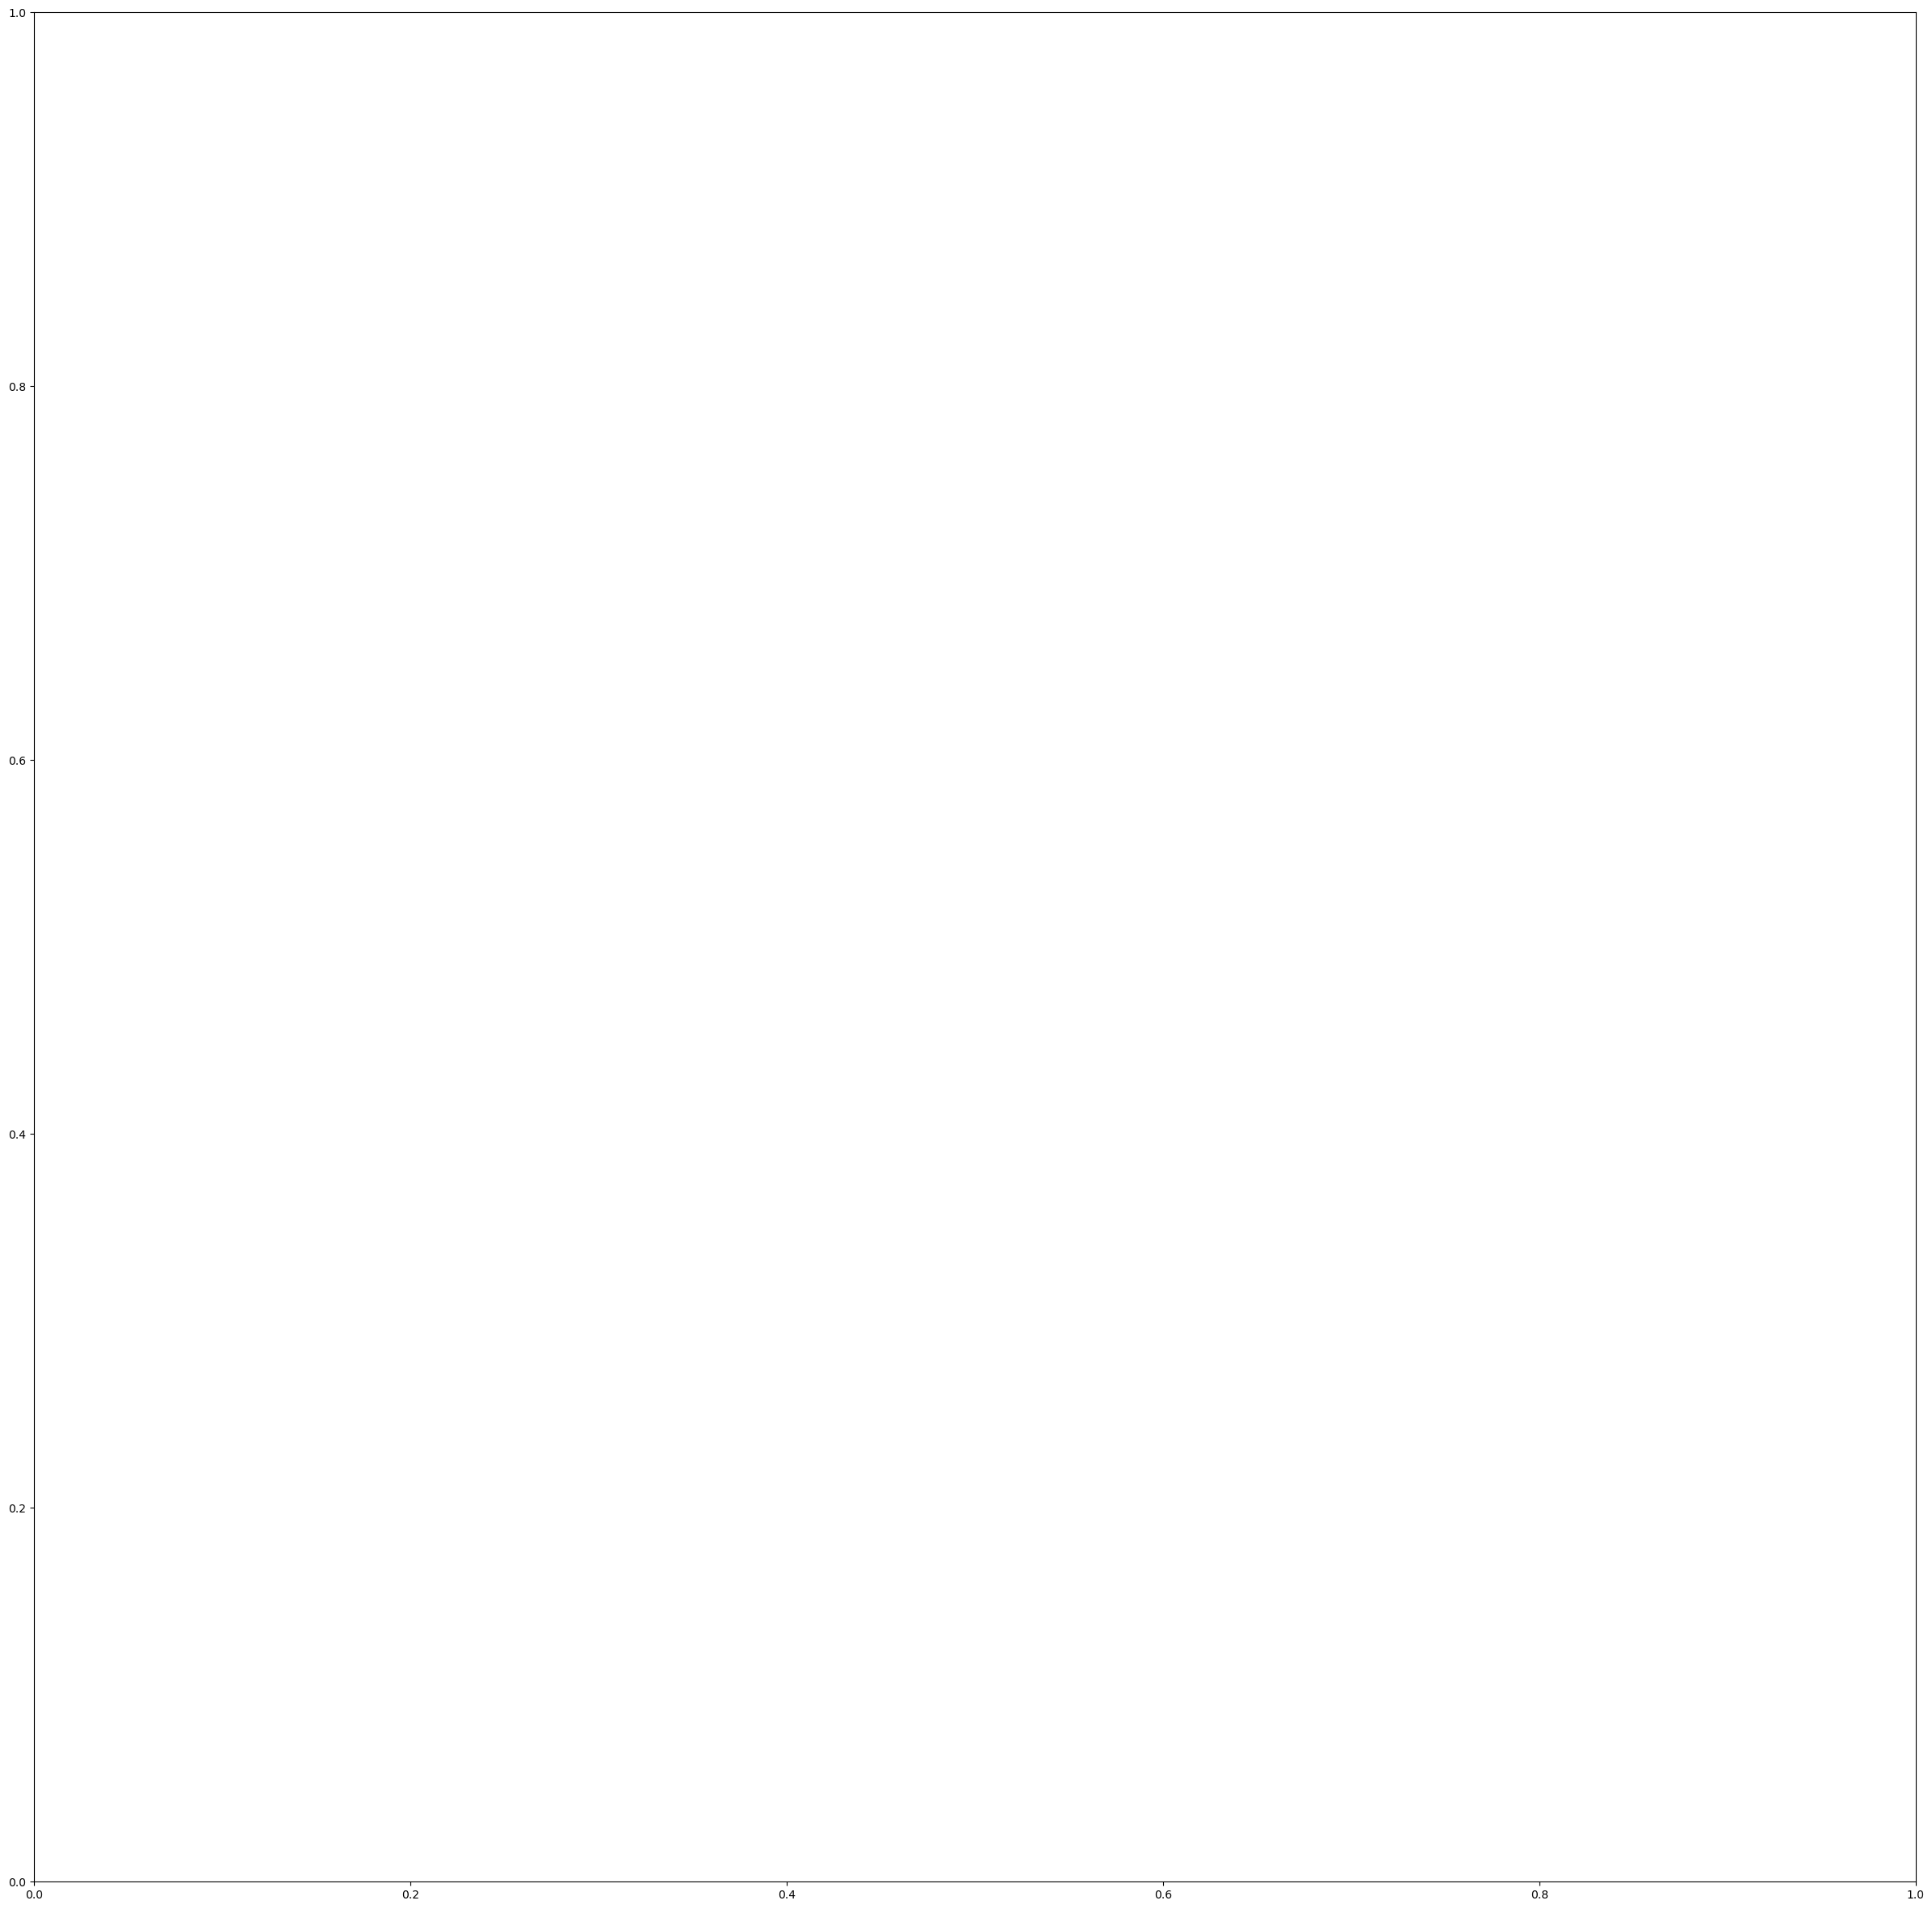

In [32]:
# Install graphviz package first
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "graphviz"])

# Then import and use
from xgboost import plot_tree
import matplotlib.pyplot as plt

# Set figure size
plt.rcParams['figure.figsize'] = (30, 30)

# Plot trees with error handling
try:
    plot_tree(model, rankdir='LR', num_trees=0)
    plt.show()
    
    plot_tree(model, rankdir='LR', num_trees=1)
    plt.show()
    
    plot_tree(model, rankdir='LR', num_trees=19)
    plt.show()
except Exception as e:
    print(f"Error plotting tree: {e}")
    print("Make sure Graphviz is installed on your system")

In [33]:
trees=model.get_booster().get_dump()
len(trees)
print(trees[0])

0:[DayOfWeek_7<1] yes=1,no=2,missing=2
	1:[StateHoliday_0<1] yes=3,no=4,missing=4
		3:[StoreType_b<1] yes=7,no=8,missing=8
			7:[Day<0.966666639] yes=15,no=16,missing=16
				15:leaf=-1711.60364
				16:leaf=-1562.98352
			8:[Store<0.235188514] yes=17,no=18,missing=18
				17:leaf=4050.27881
				18:leaf=1377.86133
		4:[Promo<1] yes=9,no=10,missing=10
			9:[Assortment_a<1] yes=19,no=20,missing=20
				19:leaf=162.499649
				20:leaf=-75.6181488
			10:[DayOfWeek_1<1] yes=21,no=22,missing=22
				21:leaf=611.443298
				22:leaf=1191.70276
	2:[StoreType_b<1] yes=5,no=6,missing=6
		5:[CompetitionDistance<0.355617076] yes=11,no=12,missing=12
			11:[CompetitionDistance<0.153744727] yes=23,no=24,missing=24
				23:leaf=-1730.08411
				24:leaf=-1707.35352
			12:[Assortment_a<1] yes=25,no=26,missing=26
				25:leaf=-1510.23108
				26:leaf=-1730.92847
		6:[Store<0.235188514] yes=13,no=14,missing=14
			13:[Store<0.0780969486] yes=27,no=28,missing=28
				27:leaf=1656.15405
				28:leaf=4705.97461
			14:[Asso

In [34]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance',ascending=False)
importance_df.head(10)

,feature,importance
18,DayOfWeek_7,0.482139
19,StateHoliday_0,0.166632
1,Promo,0.112967
12,DayOfWeek_1,0.036890
24,StoreType_b,0.030102
10,WeekOfYear,0.022943
5,Promo2,0.022058
27,Assortment_a,0.020405
16,DayOfWeek_5,0.013023
13,DayOfWeek_2,0.010475


<Axes: title={'center': 'Feature importance'}, xlabel='importance', ylabel='feature'>

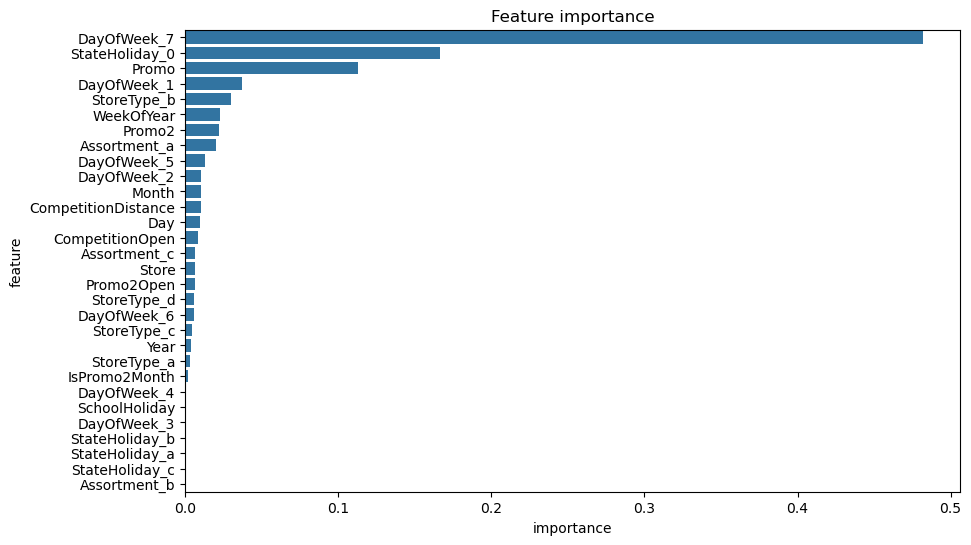

In [35]:
plt.figure(figsize=(10,6))
plt.title('Feature importance')
sns.barplot(data=importance_df,x='importance',y='feature')

In [36]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

def train_and_evaluate(Xtrain, train_targets, X_val, val_targets, **params):
    # Initialize model with given parameters
    model = XGBRegressor(random_state=42, n_jobs=-1, **params)
    
    # Fit model
    model.fit(Xtrain, train_targets)
    
    # Calculate RMSE for train and validation sets
    train_rmse = rmse(train_targets, model.predict(Xtrain))
    val_rmse = rmse(val_targets, model.predict(X_val))
    
    return model, train_rmse, val_rmse

In [37]:
Kfold=KFold(n_splits=5)

In [38]:
models = []

for train_idxs, val_idxs in Kfold.split(X):
    X_train, train_targets = X.iloc[train_idxs], targets.iloc[train_idxs]
    X_val, val_targets = X.iloc[val_idxs], targets.iloc[val_idxs]
    
    model, train_rmse, val_rmse = train_and_evaluate(
        X_train,
        train_targets,
        X_val,
        val_targets,
        max_depth=4,
        n_estimators=20
    )
    
    models.append(model)
    print('Train RMSE: {}, Validation RMSE: {}'.format(train_rmse, val_rmse))

Train RMSE: 2270.0272024801816, Validation RMSE: 2309.7034441676706
Train RMSE: 2272.850303033616, Validation RMSE: 2314.5937008468677
Train RMSE: 2296.2776400078455, Validation RMSE: 2249.347349788378
Train RMSE: 2254.6832371754576, Validation RMSE: 2316.9915839294713
Train RMSE: 2259.3424928505196, Validation RMSE: 2320.08114082245


In [39]:
def predict_avg(models,inputs):
    return np.mean([model.predict(inputs) for model in models],axis=0)

In [40]:
(models[0].predict(X) + models[1].predict(X))/2

array([8390.798 , 8004.4385, 8368.828 , ...,  237.3635, 5527.5024,
       -335.7718], dtype=float32)

In [41]:
from sklearn.model_selection import train_test_split
X_train,X_val,train_targets,val_targets=train_test_split(X,targets,test_size=0.1)

In [42]:
def test_params(**params):
    model=XGBRegressor(n_jobs=-1,random_state=42,**params)
    model.fit(X_train,train_targets)
    train_rmse=rmse(train_targets,model.predict(X_train))
    val_rmse=rmse(val_targets,model.predict(X_val))
    print('Train RMSE:{},Validation RMSE:{}'.format(train_rmse,val_rmse))

In [43]:
test_params(n_estimators=10)

Train RMSE:2283.8927295300014,Validation RMSE:2282.3584293445233


In [44]:
test_params(n_estimators=30)

Train RMSE:1901.247222220193,Validation RMSE:1901.8768361805135


In [45]:
test_params(n_estimators=100) # when the val accuracy drops then you know the model is overfitting 

Train RMSE:1252.1944737140473,Validation RMSE:1257.6470092995094


In [46]:
test_params(max_depth=10,n_estimators=100)

Train RMSE:694.9033430988802,Validation RMSE:775.1873563855386


In [47]:
test_params(n_estimators=100,max_depth=10,learning_rate=0.5)

Train RMSE:618.714392914857,Validation RMSE:733.9203379795384


In [48]:
test_params(booster='gblinear') # performs gradient boosting on multiple linear models

Train RMSE:2555.008708400032,Validation RMSE:2550.9297324701047


In [49]:
model=XGBRegressor(n_jobs=-1,random_state=42,n_estimators=100,max_depth=10,learning_rate=0.5,subsample=0.9,colsample_bytree=0.7)
model.fit(X,targets)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [50]:
test_preds=model.predict(X_test)
print(test_preds)

[ 3942.3586  8182.612   9001.807  ...  6516.2764 23961.516   8089.957 ]


In [51]:
sample_input = {
    'Store': 2,
    'DayOfWeek': 4,
    'Promo':1,
    'Date': '2015-09-30',
    'Open': 1,
    'StateHoliday':'a',
    'SchoolHoliday':0
}

input_df2=pd.DataFrame([sample_input])
merged_input_df=input_df2.merge(store_df,on='Store')
merged_input_df

,Store,DayOfWeek,Promo,Date,Open,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,2,4,1,2015-09-30,1,a,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"


In [52]:
#feature engineering 
split_date(merged_input_df)
comp_months(merged_input_df)
promo_cols(merged_input_df)

In [53]:
from sklearn.preprocessing import OneHotEncoder

# Ensure categorical columns are strings
merged_input_df[categorical_cols] = merged_input_df[categorical_cols].astype(str)

# Scale numeric columns using the trained scaler
merged_input_df[numeric_cols] = scaler.transform(merged_input_df[numeric_cols])

# Use the encoder that was already fit on training data
# Don't refit - use the encoder from earlier in your notebook
encoded_cols_list = list(encoder.get_feature_names_out(categorical_cols))

# Transform using the pre-trained encoder
merged_input_df[encoded_cols_list] = encoder.transform(merged_input_df[categorical_cols])

# Drop original categorical columns
merged_input_df = merged_input_df.drop(columns=categorical_cols)

# Build input features in the same order the model was trained on
X_input = merged_input_df[model.feature_names_in_]

# Predict
prediction = model.predict(X_input)
print(prediction)

[-2007.4197]


In [54]:
# 1. Check your target variable - remove rows with Sales <= 0
print("Sales statistics:")
print(f"Min: {targets.min()}, Max: {targets.max()}, Mean: {targets.mean()}")

# Filter out closed stores (Open=0) and zero/negative sales
valid_mask = (merged_df['Open'] == 1) & (merged_df['Sales'] > 0)
inputs_clean = inputs[valid_mask].copy()
targets_clean = targets[valid_mask].copy()

print(f"Original samples: {len(targets)}, Clean samples: {len(targets_clean)}")

# 2. Retrain with cleaned data
X_clean = inputs_clean[numeric_cols + encoded_cols]

model = XGBRegressor(
    n_jobs=-1,
    random_state=42,
    n_estimators=100,
    max_depth=5,  # Reduced depth
    learning_rate=0.1,  # Lower learning rate
    subsample=0.9,
    colsample_bytree=0.7,
    min_child_weight=1,  # Prevents extreme predictions
    objective='reg:squarederror'
)

model.fit(X_clean, targets_clean)

# 3. Test on your sample
prediction = model.predict(X_input)
print(f"New Prediction: {prediction[0]:.2f}")

# 4. Add post-processing to ensure positive predictions
prediction = max(0, prediction[0])  # Floor at 0
print(f"Adjusted Prediction: {prediction:.2f}")

Sales statistics:
Min: 0, Max: 41551, Mean: 5773.818972305593
Original samples: 1017209, Clean samples: 844338
New Prediction: 7534.15
Adjusted Prediction: 7534.15


In [55]:
# Create a realistic sample dictionary with all required features
sample_input = {
    'Store': 5,
    'DayOfWeek': 3,
    'Promo': 1,
    'Date': '2015-09-17',
    'Open': 1,
    'StateHoliday': '0',
    'SchoolHoliday': 0
}

# Convert to DataFrame
input_df = pd.DataFrame([sample_input])

# Merge with store data to get store-specific features
merged_input_df = input_df.merge(store_df, on='Store')

print("After merge:")
print(merged_input_df[['Store', 'StoreType', 'Assortment', 'CompetitionDistance']])

# === FEATURE ENGINEERING ===
# Apply all transformations
split_date(merged_input_df)
comp_months(merged_input_df)
promo_cols(merged_input_df)

print("\nAfter feature engineering:")
print(merged_input_df[['Date', 'Year', 'Month', 'Day', 'CompetitionOpen', 'Promo2Open']])

# === HANDLE MISSING VALUES ===
# Fill CompetitionDistance if missing
if merged_input_df['CompetitionDistance'].isna().any():
    merged_input_df['CompetitionDistance'].fillna(max_distance, inplace=True)

print("\nAfter filling missing values:")
print(merged_input_df[numeric_cols + categorical_cols])

# === SCALE NUMERIC COLUMNS ===
merged_input_df[numeric_cols] = scaler.transform(merged_input_df[numeric_cols])

print("\nAfter scaling numeric columns:")
print(merged_input_df[numeric_cols])

# === ENCODE CATEGORICAL COLUMNS ===
# Ensure categorical columns are strings
merged_input_df[categorical_cols] = merged_input_df[categorical_cols].astype(str)

# Get encoded column names (using pre-trained encoder)
encoded_cols_list = list(encoder.get_feature_names_out(categorical_cols))

# Transform using pre-trained encoder
merged_input_df[encoded_cols_list] = encoder.transform(merged_input_df[categorical_cols])

print("\nAfter encoding categorical columns:")
print(merged_input_df[encoded_cols_list])

# Drop original categorical columns
merged_input_df = merged_input_df.drop(columns=categorical_cols)

# === BUILD INPUT FEATURES IN CORRECT ORDER ===
X_input = merged_input_df[model.feature_names_in_]

print("\nFinal input features:")
print(X_input)

# === MAKE PREDICTION ===
prediction = model.predict(X_input)
prediction_value = max(0, prediction[0])  # Ensure non-negative

print(f"\n{'='*50}")
print(f"PREDICTION: {prediction_value:.2f}")
print(f"{'='*50}")

After merge:
   Store StoreType Assortment  CompetitionDistance
0      5         a          a              29910.0

After feature engineering:
        Date  Year  Month  Day  CompetitionOpen  Promo2Open
0 2015-09-17  2015      9   17              5.0           0

After filling missing values:
   Store  Promo  SchoolHoliday  CompetitionDistance  CompetitionOpen  Promo2  \
0      5      1              0              29910.0              5.0       0   

   Promo2Open  Day  Month  Year  WeekOfYear  IsPromo2Month  DayOfWeek  \
0           0   17      9  2015          38              0          3   

  StateHoliday StoreType Assortment  
0            0         a          a  

After scaling numeric columns:
      Store  Promo  SchoolHoliday  CompetitionDistance  CompetitionOpen  \
0  0.003591    1.0            0.0             0.394119         0.003608   

   Promo2  Promo2Open       Day     Month  Year  WeekOfYear  IsPromo2Month  
0     0.0         0.0  0.533333  0.727273   1.0     0.72549   

In [57]:
# Install required packages
!pip install streamlit pandas joblib numpy scikit-learn xgboost

In [59]:
import joblib

# Save model, scaler, and encoder
joblib.dump(model, 'rossman_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')

print("✅ All artifacts saved successfully!")
print("Files created:")
print("  - rossman_model.pkl")
print("  - scaler.pkl")
print("  - encoder.pkl")

✅ All artifacts saved successfully!
Files created:
  - rossman_model.pkl
  - scaler.pkl
  - encoder.pkl


In [60]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np
from datetime import datetime, timedelta

# Set page config
st.set_page_config(
    page_title="Rossman Sales Predictor",
    page_icon="🏪",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for better aesthetics
st.markdown("""
    <style>
    .main {
        padding: 2rem;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    }
    .stMetric {
        background-color: white;
        padding: 1rem;
        border-radius: 0.5rem;
        box-shadow: 0 2px 8px rgba(0,0,0,0.1);
    }
    h1 {
        color: white;
        text-align: center;
        font-size: 2.5rem;
        margin-bottom: 0.5rem;
    }
    h2 {
        color: #333;
        border-bottom: 3px solid #667eea;
        padding-bottom: 0.5rem;
    }
    .prediction-box {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 2rem;
        border-radius: 1rem;
        color: white;
        text-align: center;
        margin: 2rem 0;
        box-shadow: 0 4px 12px rgba(0,0,0,0.2);
    }
    .prediction-value {
        font-size: 3rem;
        font-weight: bold;
        margin: 1rem 0;
    }
    .info-box {
        background-color: #f0f2f6;
        padding: 1rem;
        border-radius: 0.5rem;
        border-left: 4px solid #667eea;
        margin: 1rem 0;
    }
    </style>
""", unsafe_allow_html=True)

# Load models and artifacts
@st.cache_resource
def load_artifacts():
    model = joblib.load('rossman_model.pkl')
    scaler = joblib.load('scaler.pkl')
    encoder = joblib.load('encoder.pkl')
    store_df = pd.read_csv('C:/Users/nanda/Downloads/store.csv')
    return model, scaler, encoder, store_df

# Feature engineering functions
def split_date(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df.Date.dt.year
    df['Month'] = df.Date.dt.month
    df['Day'] = df.Date.dt.day
    df['WeekOfYear'] = df.Date.dt.isocalendar().week

def comp_months(df):
    df['CompetitionOpen'] = (
        (df['Year'] - df['CompetitionOpenSinceYear']) * 12 +
        (df['Month'] - df['CompetitionOpenSinceMonth'])
    )
    df['CompetitionOpen'] = df['CompetitionOpen'].apply(lambda x: 0 if pd.isna(x) or x < 0 else x)

def promo_cols(df):
    df['Promo2Open'] = (
        (df['Year'] - df['Promo2SinceYear']) * 12 +
        (df['WeekOfYear'] - df['Promo2SinceWeek']) // 4
    )
    df['Promo2Open'] = df['Promo2Open'].apply(lambda x: 0 if pd.isna(x) or x < 0 else x)
    df['Promo2Open'] = df['Promo2Open'] * df['Promo2']
    
    month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'}
    
    def is_promo_month(row):
        months = str(row['PromoInterval']).split(',') if pd.notna(row['PromoInterval']) else []
        return int(row['Promo2'] and month_map[row['Month']] in months)
    
    df['IsPromo2Month'] = df.apply(is_promo_month, axis=1)

def make_prediction(sample_input, model, scaler, encoder, store_df):
    """Process input and make prediction"""
    numeric_cols = ['Store', 'Promo', 'SchoolHoliday',
                    'CompetitionDistance', 'CompetitionOpen', 'Promo2', 'Promo2Open',
                    'Day', 'Month', 'Year', 'WeekOfYear', 'IsPromo2Month']
    
    categorical_cols = ['DayOfWeek', 'StateHoliday', 'StoreType', 'Assortment']
    
    # Create DataFrame
    input_df = pd.DataFrame([sample_input])
    merged_input_df = input_df.merge(store_df, on='Store')
    
    # Feature engineering
    split_date(merged_input_df)
    comp_months(merged_input_df)
    promo_cols(merged_input_df)
    
    # Handle missing values
    max_distance = 75860  # From training data
    if merged_input_df['CompetitionDistance'].isna().any():
        merged_input_df['CompetitionDistance'].fillna(max_distance, inplace=True)
    
    # Scale numeric columns
    merged_input_df[numeric_cols] = scaler.transform(merged_input_df[numeric_cols])
    
    # Encode categorical columns
    merged_input_df[categorical_cols] = merged_input_df[categorical_cols].astype(str)
    encoded_cols_list = list(encoder.get_feature_names_out(categorical_cols))
    merged_input_df[encoded_cols_list] = encoder.transform(merged_input_df[categorical_cols])
    merged_input_df = merged_input_df.drop(columns=categorical_cols)
    
    # Build input and predict
    X_input = merged_input_df[model.feature_names_in_]
    prediction = model.predict(X_input)
    
    return max(0, prediction[0])

# Load artifacts
model, scaler, encoder, store_df = load_artifacts()

# Header
st.markdown("<h1>🏪 Rossman Sales Predictor</h1>", unsafe_allow_html=True)
st.markdown("<p style='text-align: center; color: white; font-size: 1.1rem;'>Predict daily sales for Rossman stores</p>", 
            unsafe_allow_html=True)

# Create tabs
tab1, tab2, tab3 = st.tabs(["📊 Prediction", "ℹ️ Information", "📈 Analytics"])

with tab1:
    st.markdown("<h2>Prediction Input</h2>", unsafe_allow_html=True)
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.markdown("### Store Information")
        store_id = st.number_input(
            "Store ID",
            min_value=1,
            max_value=1115,
            value=5,
            help="Select a store number from 1 to 1115"
        )
        
        date = st.date_input(
            "Date",
            value=datetime(2015, 9, 17),
            help="Select the date for prediction"
        )
        
        day_of_week = st.selectbox(
            "Day of Week",
            options=[1, 2, 3, 4, 5, 6, 7],
            format_func=lambda x: ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"][x-1],
            help="Select the day of week"
        )
    
    with col2:
        st.markdown("### Promotions & Holidays")
        promo = st.checkbox("Promotion Active", value=True)
        school_holiday = st.checkbox("School Holiday", value=False)
        
        state_holiday = st.selectbox(
            "State Holiday",
            options=['0', 'a', 'b', 'c'],
            format_func=lambda x: {'0': 'None', 'a': 'Holiday A', 'b': 'Holiday B', 'c': 'Holiday C'}[x],
            help="Select state holiday type"
        )
    
    # Create sample input
    sample_input = {
        'Store': store_id,
        'DayOfWeek': day_of_week,
        'Promo': int(promo),
        'Date': str(date),
        'Open': 1,
        'StateHoliday': state_holiday,
        'SchoolHoliday': int(school_holiday)
    }
    
    # Predict button
    col1, col2, col3 = st.columns([1, 1, 1])
    with col2:
        predict_button = st.button("🎯 Predict Sales", use_container_width=True, type="primary")
    
    if predict_button:
        try:
            with st.spinner("🔄 Making prediction..."):
                prediction = make_prediction(sample_input, model, scaler, encoder, store_df)
            
            # Display prediction
            st.markdown(f"""
                <div class='prediction-box'>
                    <h3>Predicted Sales</h3>
                    <div class='prediction-value'>€ {prediction:,.2f}</div>
                    <p style='font-size: 0.9rem; opacity: 0.9;'>for Store {store_id} on {date.strftime('%B %d, %Y')}</p>
                </div>
            """, unsafe_allow_html=True)
            
            # Display input summary
            st.markdown("<h3>📋 Input Summary</h3>", unsafe_allow_html=True)
            summary_col1, summary_col2 = st.columns(2)
            
            with summary_col1:
                st.metric("Store ID", store_id)
                st.metric("Date", date.strftime("%B %d, %Y"))
                st.metric("Day", ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"][day_of_week-1])
            
            with summary_col2:
                st.metric("Promotion Active", "✅ Yes" if promo else "❌ No")
                st.metric("School Holiday", "✅ Yes" if school_holiday else "❌ No")
                st.metric("State Holiday", {'0': 'None', 'a': 'Holiday A', 'b': 'Holiday B', 'c': 'Holiday C'}[state_holiday])
        
        except Exception as e:
            st.error(f"❌ Error making prediction: {str(e)}")

with tab2:
    st.markdown("<h2>About This Model</h2>", unsafe_allow_html=True)
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.markdown("""
            <div class='info-box'>
            <h3>📊 Model Details</h3>
            <ul>
                <li><b>Algorithm:</b> XGBoost Regressor</li>
                <li><b>Features:</b> 27 (numeric + encoded categorical)</li>
                <li><b>Training Data:</b> Rossman store sales history</li>
                <li><b>Preprocessing:</b> MinMax Scaling + One-Hot Encoding</li>
            </ul>
            </div>
        """, unsafe_allow_html=True)
    
    with col2:
        st.markdown("""
            <div class='info-box'>
            <h3>🎯 How to Use</h3>
            <ol>
                <li>Select a store ID (1-1115)</li>
                <li>Choose a date for prediction</li>
                <li>Set promotion and holiday flags</li>
                <li>Click "Predict Sales"</li>
                <li>View the estimated sales amount</li>
            </ol>
            </div>
        """, unsafe_allow_html=True)
    
    st.markdown("""
        <div class='info-box'>
        <h3>📝 Features Used</h3>
        <b>Numeric Features:</b> Store, Promo, SchoolHoliday, CompetitionDistance, CompetitionOpen, 
        Promo2, Promo2Open, Day, Month, Year, WeekOfYear, IsPromo2Month
        
        <br><br><b>Categorical Features:</b> DayOfWeek, StateHoliday, StoreType, Assortment
        </div>
    """, unsafe_allow_html=True)

with tab3:
    st.markdown("<h2>📈 Model Performance</h2>", unsafe_allow_html=True)
    
    # Display model metrics
    col1, col2, col3 = st.columns(3)
    
    with col1:
        st.metric(
            "Model Type",
            "XGBoost",
            delta="Gradient Boosting"
        )
    
    with col2:
        st.metric(
            "Total Features",
            "27",
            delta="After preprocessing"
        )
    
    with col3:
        st.metric(
            "Stores Covered",
            "1115",
            delta="Active stores"
        )
    
    st.markdown("""
        <div class='info-box'>
        <h3>🚀 Model Capabilities</h3>
        <ul>
            <li>✅ Predicts daily sales for any store</li>
            <li>✅ Considers promotions and holidays</li>
            <li>✅ Factors in competition distance</li>
            <li>✅ Accounts for store type and assortment</li>
            <li>✅ Utilizes seasonal patterns</li>
        </ul>
        </div>
    """, unsafe_allow_html=True)

# Footer
st.markdown("---")
st.markdown("""
    <div style='text-align: center; color: #888; font-size: 0.9rem;'>
    <p>Rossman Sales Predictor | Built with Streamlit & XGBoost | 2024</p>
    </div>
""", unsafe_allow_html=True)

2026-03-23 12:55:30.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 12:55:30.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 12:55:30.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 12:55:30.781 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 12:55:30.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 12:55:30.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 12:55:30.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 12:55:30.838 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()